# Grocery Product Image Generation Using Basic GAN

**Approved dataset:** GroceryStoreDataset (Marcus Klasson)  
**Image size:** 64×64 RGB  
**Model:** Basic GAN

### Objective
Generate synthetic grocery-product-like images by learning the visual distribution of real grocery-product images.

### Required concepts
Generator • Discriminator • Latent Space • Random Noise • Binary Cross-Entropy • Adam • GAN Training Loop • Generated Images • Loss Analysis • Training Comparison


# Real-World Requirement
Grocery retailers and e-commerce teams need product visuals for catalogs, mock-ups and digital planning. Manual photography and editing can require time and resources.

**Solution:** train a Basic GAN to learn grocery-product visual patterns and generate synthetic product-like images.

**Input:** random latent noise.  
**Output:** 64×64 RGB synthetic image.  
**Use:** visual ideation/prototyping, not verified product photography.

**Evaluation:** losses, generated-image progression, FID, KID, diversity/brightness diagnostics, and three experiments.

In [2]:
import os, random, json, time, hashlib, zipfile, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import tensorflow as tf
from scipy.linalg import sqrtm
from tensorflow.keras.applications.inception_v3 import (
    InceptionV3,
    preprocess_input
)
ImageFile.LOAD_TRUNCATED_IMAGES=True
SEED=42
random.seed(SEED);
np.random.seed(SEED);
tf.random.set_seed(SEED)
print("TensorFlow:",tf.__version__)
print("GPU:",bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.21.0
GPU: False


In [3]:
PROJECT_DIR=Path.cwd()/"GroceryStore_GAN_Project"
OUTPUT_DIR=PROJECT_DIR/"outputs";
MODEL_DIR=PROJECT_DIR/"model"
for p in [OUTPUT_DIR/"eda",OUTPUT_DIR/"training",OUTPUT_DIR/"evaluation",OUTPUT_DIR/"experiments",OUTPUT_DIR/"generated_images",OUTPUT_DIR/"reports",MODEL_DIR]: p.mkdir(parents=True,exist_ok=True)
IMAGE_SIZE=64;
LATENT_DIM=100;
BATCH_SIZE=16;
EPOCHS=30
TRAIN_LIMIT=2000;
VAL_LIMIT=300;
TEST_EVAL_LIMIT=300
MODEL_SCOPE="all";
TARGET_VALUE=None
print("Project output:",OUTPUT_DIR.resolve())

Project output: C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\outputs


# Dataset Download  

In [4]:
REPO_URL="https://github.com/marcusklasson/GroceryStoreDataset/archive/refs/heads/master.zip"
DATA_ROOT=PROJECT_DIR/"data"; DATA_ROOT.mkdir(exist_ok=True)
zip_path=DATA_ROOT/"GroceryStoreDataset.zip"
if not any(DATA_ROOT.rglob("*.jpg")) and not any(DATA_ROOT.rglob("*.jpeg")) and not any(DATA_ROOT.rglob("*.png")):
    urllib.request.urlretrieve(REPO_URL,zip_path)
    with zipfile.ZipFile(zip_path) as z: z.extractall(DATA_ROOT)
image_files=[p for p in DATA_ROOT.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".webp"}]
print("Images found:",len(image_files))

Images found: 5522


# Image Manifest and Quality Checks
The manifest records path, dimensions, mode, format and file size. It also checks unreadable images and duplicate file hashes.

In [5]:
rows=[]
for p in image_files:
    r={"path":str(p),"extension":p.suffix.lower()}
    try:
        with Image.open(p) as im:
            r.update(width=im.width,height=im.height,mode=im.mode,format=im.format,valid=True,error="")
    except Exception as e:
        r.update(width=np.nan,height=np.nan,mode="",format="",valid=False,error=str(e))
    rows.append(r)
manifest=pd.DataFrame(rows)
valid_df=manifest[manifest.valid].copy()
manifest.to_csv(OUTPUT_DIR/"reports"/"image_manifest.csv",index=False)
print("Valid:",len(valid_df)," Invalid:",len(manifest)-len(valid_df))

Valid: 5522  Invalid: 0


# EDA 
Saved plots:
1 format • 2 mode • 3 width • 4 height • 5 aspect ratio • 6 file size • 7 width/height • 8 common dimensions • 9 real samples • 10 brightness • 11 contrast • 12 folder distribution

In [6]:
eda=OUTPUT_DIR/"eda"
def save(name):
    plt.tight_layout();
    plt.savefig(eda/name,dpi=140,bbox_inches="tight");
    plt.show();
    plt.close()

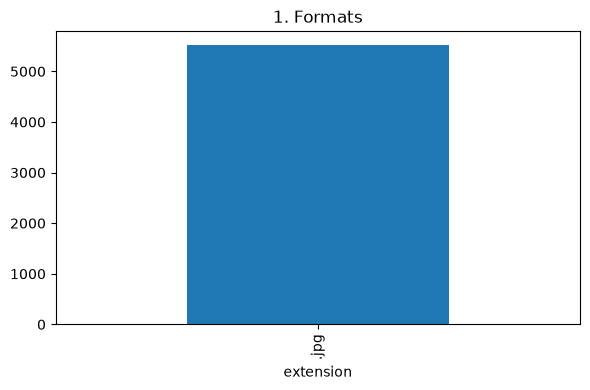

In [7]:
plt.figure(figsize=(6,4)); 
valid_df.extension.value_counts().plot.bar(); 
plt.title("1. Formats"); 
save("01_formats.png")

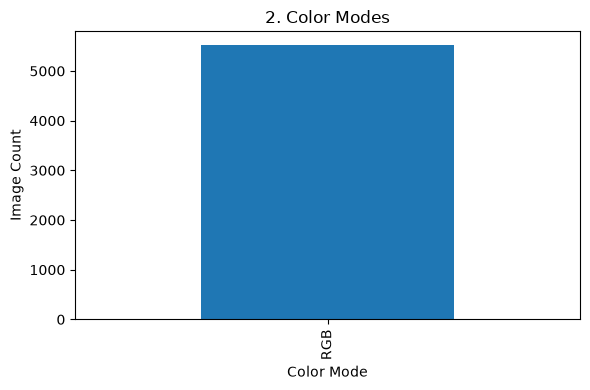

In [8]:
plt.figure(figsize=(6,4))
valid_df["mode"].value_counts().plot.bar()
plt.title("2. Color Modes")
plt.xlabel("Color Mode")
plt.ylabel("Image Count")
plt.tight_layout()
save("02_modes.png")
plt.show()

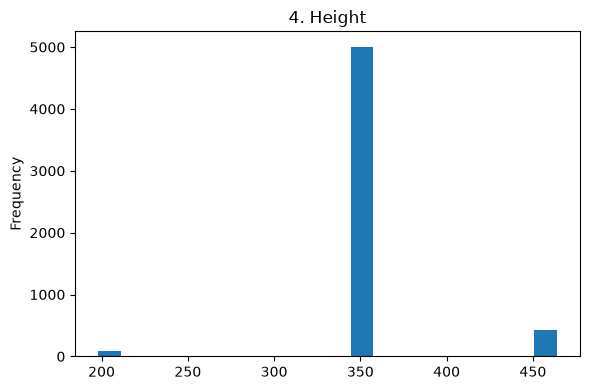

In [9]:
plt.figure(figsize=(6,4));
valid_df.height.plot.hist(bins=20);
plt.title("4. Height");
save("04_height.png")

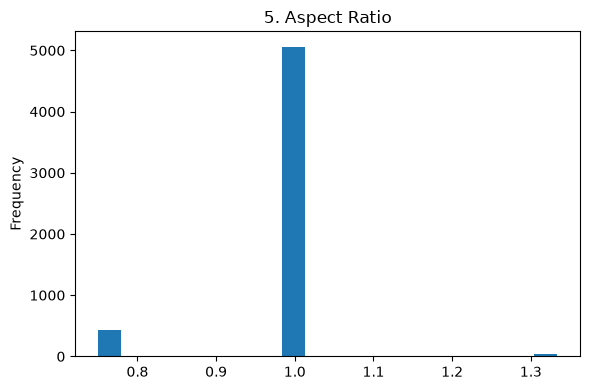

In [10]:
plt.figure(figsize=(6,4)); 
(valid_df.width/valid_df.height).plot.hist(bins=20); 
plt.title("5. Aspect Ratio"); 
save("05_aspect.png")

In [11]:
plt.figure(figsize=(6,4));
valid_df.filesize_bytes=valid_df.path.map(lambda p:Path(p).stat().st_size) if "filesize_bytes" not in valid_df else valid_df.filesize_bytes

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11288\598620445.py:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  valid_df.filesize_bytes=valid_df.path.map(lambda p:Path(p).stat().st_size) if "filesize_bytes" not in valid_df else valid_df.filesize_bytes


<Figure size 600x400 with 0 Axes>

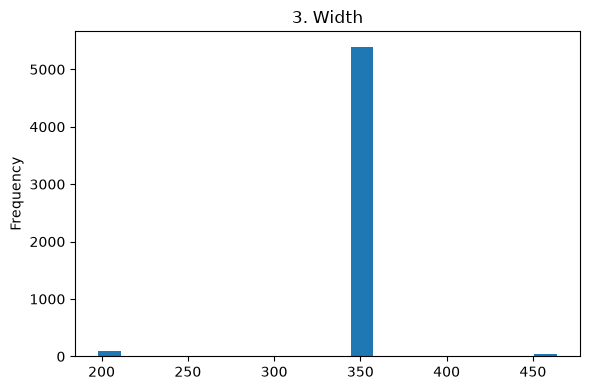

In [12]:
plt.figure(figsize=(6,4)); 
valid_df.width.plot.hist(bins=20); 
plt.title("3. Width");
save("03_width.png")

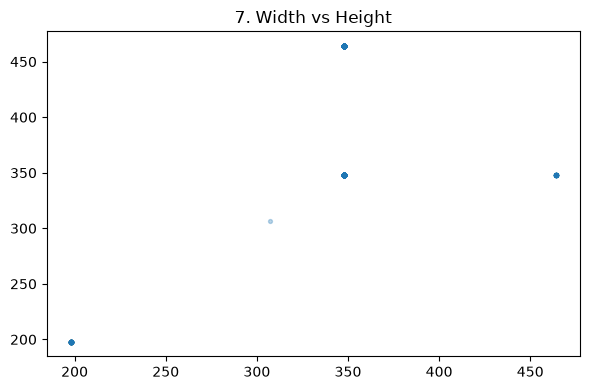

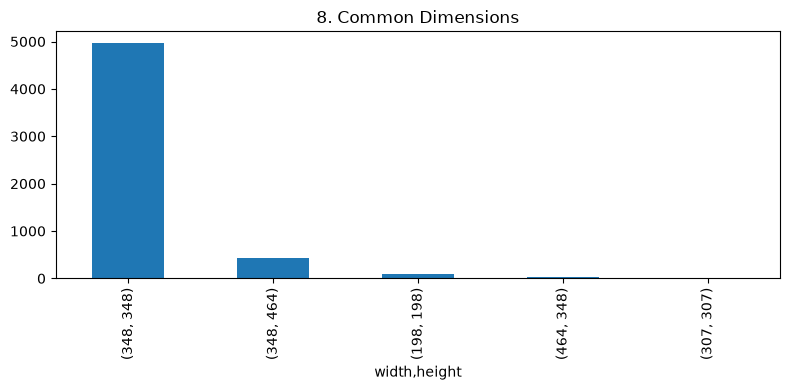

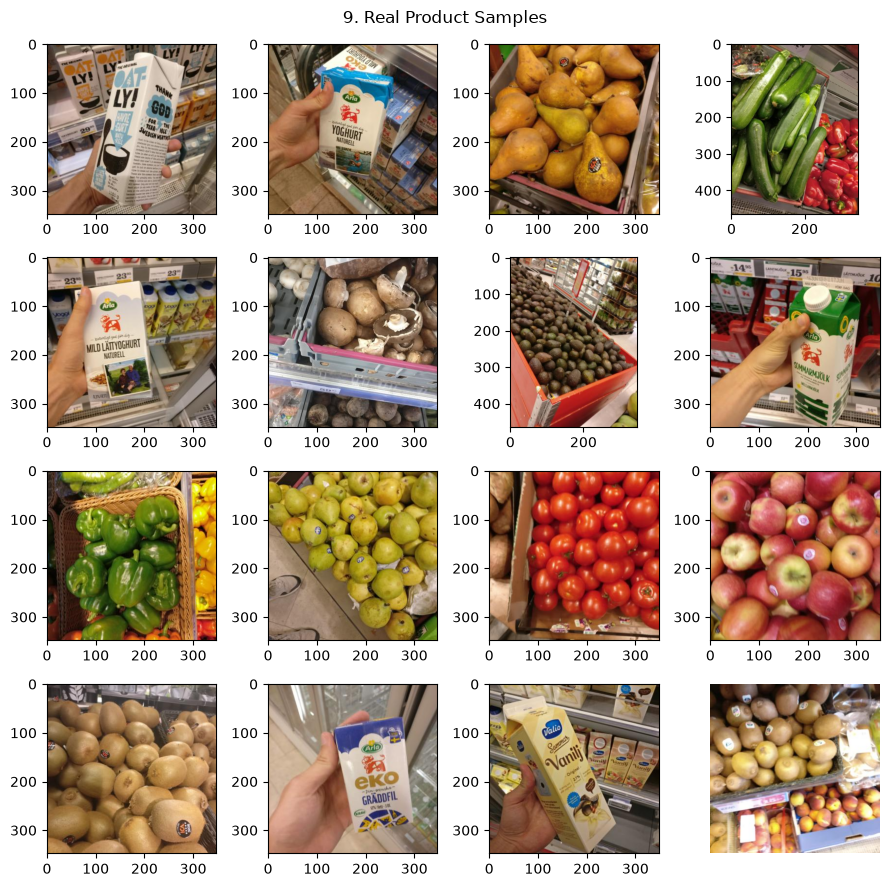

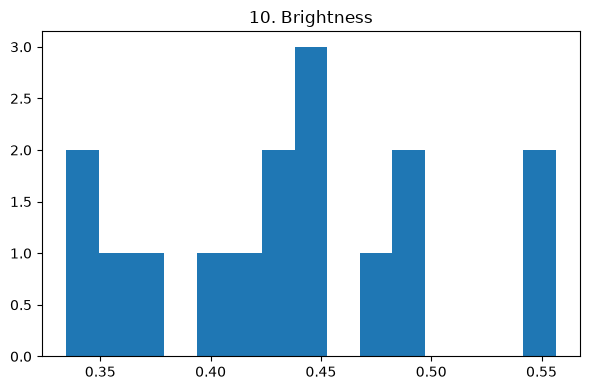

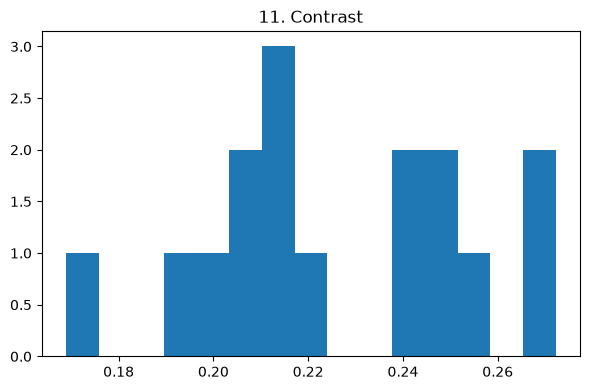

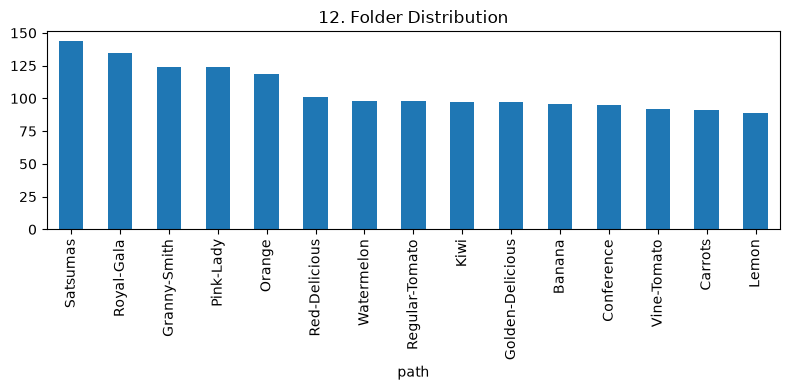

In [13]:
plt.figure(figsize=(6,4));
plt.scatter(valid_df.width,valid_df.height,s=8,alpha=.3);
plt.title("7. Width vs Height");
save("07_dimensions.png")
dims=valid_df.groupby(["width","height"]).size().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,4));
dims.plot.bar();
plt.title("8. Common Dimensions");
save("08_common_dimensions.png")
sample=valid_df.sample(min(16,len(valid_df)),random_state=SEED).path.tolist()

fig,ax=plt.subplots(4,4,figsize=(9,9))
for a,p in zip(ax.flat,sample): a.imshow(Image.open(p).convert("RGB"));
a.axis("off")
plt.suptitle("9. Real Product Samples");
plt.tight_layout();
plt.savefig(eda/"09_samples.png",dpi=140);
plt.show();
plt.close()

stats=[]
for p in sample:
    a=np.asarray(Image.open(p).convert("RGB").resize((64,64)),dtype=np.float32)/255
    stats.append([a.mean(),a.std()])
stats=np.array(stats)

plt.figure(figsize=(6,4));
plt.hist(stats[:,0],bins=15);
plt.title("10. Brightness");
save("10_brightness.png")

plt.figure(figsize=(6,4));
plt.hist(stats[:,1],bins=15);
plt.title("11. Contrast");
save("11_contrast.png")
groups=valid_df.path.map(lambda p:Path(p).parent.name)

plt.figure(figsize=(8,4));
groups.value_counts().head(15).plot.bar();
plt.title("12. Folder Distribution");
save("12_folders.png")

# 6. Train / Validation / Test
A deterministic group-aware 70/15/15 split is created. The group is the immediate image folder, reducing the chance that the same product folder appears in multiple splits.

In [14]:
df=valid_df.copy();
df["group"]=df.path.map(lambda p:Path(p).parent.name)
rng=np.random.default_rng(SEED);
gs=df.group.unique();
rng.shuffle(gs)
a=int(.70*len(gs));
b=int(.85*len(gs))
tr,va=set(gs[:a]),set(gs[a:b])
train_df=df[df.group.isin(tr)].copy();
val_df=df[df.group.isin(va)].copy();
test_df=df[~df.group.isin(tr|va)].copy()
if len(train_df)>TRAIN_LIMIT: train_df=train_df.sample(TRAIN_LIMIT,random_state=SEED)
if len(val_df)>VAL_LIMIT: val_df=val_df.sample(VAL_LIMIT,random_state=SEED)
split=pd.DataFrame({"split":["train","validation","test"],"images":[len(train_df),len(val_df),len(test_df)]})
display(split);
split.to_csv(OUTPUT_DIR/"reports"/"split_summary.csv",index=False)
print("Leakage:",len(set(train_df.group)&set(val_df.group)),len(set(train_df.group)&set(test_df.group)),len(set(val_df.group)&set(test_df.group)))

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11288\2937721940.py:5: UserWarning: you are shuffling a 'ArrowStringArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  rng.shuffle(gs)


,split,images
0,train,2000
1,validation,300
2,test,722


Leakage: 0 0 0


# GAN Preprocessing
Images are converted to RGB, resized to 64×64 and normalized from [0,255] to [-1,1]. The Generator uses `tanh`(generator final activation), so this range is intentional.

In [15]:
AUTOTUNE=tf.data.AUTOTUNE
def load_image(path):
    x=tf.io.read_file(path);
    x=tf.image.decode_image(x,channels=3,expand_animations=False)
    x=tf.image.resize(x,[IMAGE_SIZE,IMAGE_SIZE]);
    x=tf.cast(x,tf.float32);
    x=x/127.5-1
    x.set_shape([IMAGE_SIZE,IMAGE_SIZE,3]);
    return x

def make_ds(paths,shuffle=True):
    d=tf.data.Dataset.from_tensor_slices(paths).map(load_image,num_parallel_calls=AUTOTUNE)
    if shuffle: d=d.shuffle(max(len(paths),1),seed=SEED)
    return d.batch(BATCH_SIZE,drop_remainder=True).prefetch(1)
    
train_dataset=make_ds(train_df.path.tolist()); val_dataset=make_ds(val_df.path.tolist(),False)

# 8. Latent Space / Random Noise
The Generator receives random noise rather than a real image.

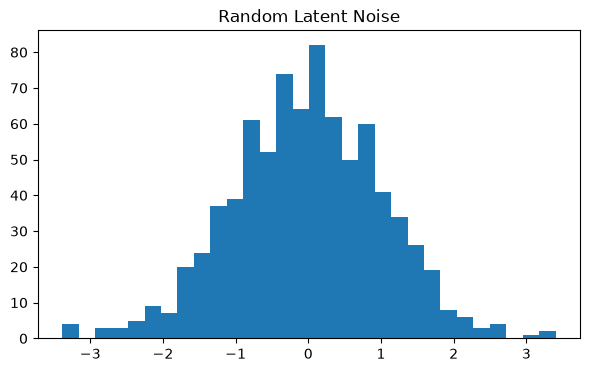

Latent shape: (8, 100)


In [16]:
noise=tf.random.normal([8,LATENT_DIM],seed=SEED)
plt.figure(figsize=(7,4));
plt.hist(noise.numpy().ravel(),bins=30);
plt.title("Random Latent Noise");
plt.savefig(OUTPUT_DIR/"reports"/"latent_noise.png",dpi=140);
plt.show()
print("Latent shape:",noise.shape)

# 9. Generator Architecture
Dense → reshape → transposed-convolution blocks → `tanh` → 64×64×3 image.

In [17]:
def build_generator(latent_dim=LATENT_DIM):
    return tf.keras.Sequential([
        tf.keras.layers.Input((latent_dim,)),
        tf.keras.layers.Dense(8*8*256,use_bias=False),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.Reshape((8,8,256)),
        tf.keras.layers.Conv2DTranspose(128,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(64,5,2,"same",use_bias=False),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.Conv2DTranspose(3,5,2,"same",activation="tanh")
    ],name="Generator")
generator=build_generator(); generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16384)          │     1,638,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 3)      │         4,803 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,733,507 (10.43 MB)

 Trainable params: 2,700,355 (10.30 MB)

 Non-trainable params: 33,152 (129.50 KB)

# Discriminator Architecture
Convolutional feature extraction → LeakyReLU → Dropout → Sigmoid real/fake probability.

In [18]:
def build_discriminator(dropout=.30):
    return tf.keras.Sequential([
        tf.keras.layers.Input((IMAGE_SIZE,IMAGE_SIZE,3)),
        tf.keras.layers.Conv2D(64,5,2,"same"),
        tf.keras.layers.LeakyReLU(.2),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Conv2D(128,5,2,"same"),
        tf.keras.layers.LeakyReLU(.2),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Conv2D(256,5,2,"same"),
        tf.keras.layers.LeakyReLU(.2),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1,activation="sigmoid")
    ],name="Discriminator")
discriminator=build_discriminator(); discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,045,633 (3.99 MB)

 Trainable params: 1,045,633 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

# Loss Function 
# BCE Loss and Adam optimizer
Binary Cross-Entropy fits the Discriminator's binary real/fake task. Adam provides adaptive gradient updates.

In [19]:
bce=tf.keras.losses.BinaryCrossentropy()
g_optimizer=tf.keras.optimizers.Adam(.0002,beta_1=.5)
d_optimizer=tf.keras.optimizers.Adam(.0002,beta_1=.5)
def g_loss(fake): return bce(tf.ones_like(fake),fake)
def d_loss(real,fake): return bce(tf.ones_like(real),real)+bce(tf.zeros_like(fake),fake)

# GAN Training Loop
Each batch:
1. Generate fake images.
2. Train Discriminator on real and fake.
3. Train Generator to make fake images look real.

In [20]:
@tf.function
def train_step(real):
    n=tf.shape(real)[0];
    z=tf.random.normal([n,LATENT_DIM])
    with tf.GradientTape() as gt,tf.GradientTape() as dt:
        fake=generator(z,training=True);
        ro=discriminator(real,training=True);
        fo=discriminator(fake,training=True)
        gl=g_loss(fo);
        dl=d_loss(ro,fo)
    generator_grads=gt.gradient(gl,generator.trainable_variables)
    discriminator_grads=dt.gradient(dl,discriminator.trainable_variables)
    g_optimizer.apply_gradients(zip(generator_grads,generator.trainable_variables))
    d_optimizer.apply_gradients(zip(discriminator_grads,discriminator.trainable_variables))
    return gl,dl

fixed_noise=tf.random.normal([16,LATENT_DIM],seed=SEED)
g_hist=[];
d_hist=[];
snapshots={}
for epoch in range(1,EPOCHS+1):
    gs=[];
    ds=[];
    start=time.time()
    for batch in train_dataset:
        a,b=train_step(batch);
        gs.append(float(a));
        ds.append(float(b))
    g_hist.append(np.mean(gs));
    d_hist.append(np.mean(ds))
    if epoch in {1, max(2, EPOCHS//3), max(3, 2*EPOCHS//3), EPOCHS}: snapshots[epoch] = generator(fixed_noise, training=False).numpy()
    print(f"Epoch {epoch}/{EPOCHS} G={g_hist[-1]:.4f} D={d_hist[-1]:.4f} time={time.time()-start:.1f}s")
history=pd.DataFrame({"epoch":range(1,EPOCHS+1),"generator_loss":g_hist,"discriminator_loss":d_hist})
history.to_csv(OUTPUT_DIR/"training"/"training_history.csv",index=False)

Epoch 1/30 G=2.8217 D=0.6442 time=81.4s
Epoch 2/30 G=2.6537 D=0.4472 time=82.0s
Epoch 3/30 G=1.6807 D=0.7714 time=83.4s
Epoch 4/30 G=1.6170 D=0.9013 time=68.5s
Epoch 5/30 G=1.3882 D=0.9156 time=68.8s
Epoch 6/30 G=1.5023 D=0.9117 time=69.3s
Epoch 7/30 G=1.3286 D=0.9504 time=68.6s
Epoch 8/30 G=1.3368 D=1.0174 time=72.6s
Epoch 9/30 G=1.3911 D=0.9162 time=68.5s
Epoch 10/30 G=1.0238 D=1.1537 time=68.2s
Epoch 11/30 G=1.2102 D=0.9833 time=69.6s
Epoch 12/30 G=1.1758 D=1.0677 time=68.7s
Epoch 13/30 G=1.2793 D=1.0023 time=68.1s
Epoch 14/30 G=1.0398 D=1.1414 time=68.4s
Epoch 15/30 G=1.1919 D=1.0368 time=69.0s
Epoch 16/30 G=1.3327 D=1.0304 time=69.5s
Epoch 17/30 G=1.0926 D=1.0702 time=70.9s
Epoch 18/30 G=1.2409 D=0.9620 time=66.6s
Epoch 19/30 G=1.1253 D=1.0170 time=66.8s
Epoch 20/30 G=1.2303 D=0.9907 time=67.6s
Epoch 21/30 G=1.2125 D=0.9786 time=70.4s
Epoch 22/30 G=1.2896 D=1.0395 time=64.9s
Epoch 23/30 G=1.2361 D=1.0197 time=65.1s
Epoch 24/30 G=1.2922 D=1.0303 time=69.2s
Epoch 25/30 G=1.2694 D=0.

# Training Loss Analysis
Use the curve to discuss stability rather than expecting one exact target loss.

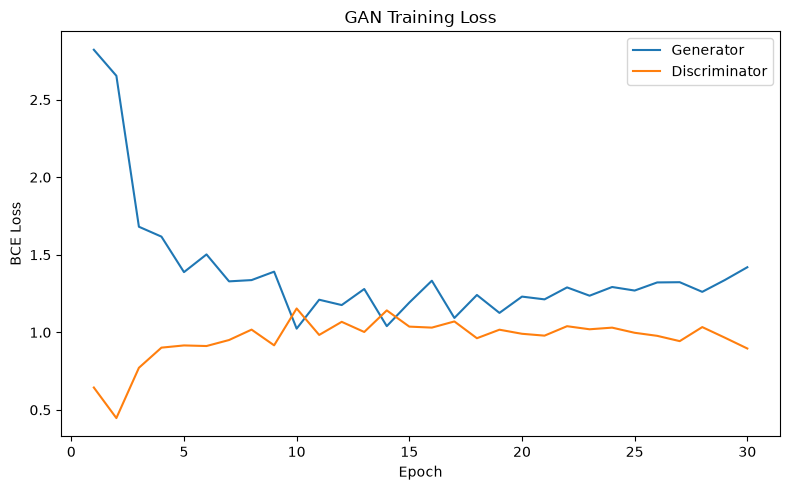

In [21]:
plt.figure(figsize=(8,5));
plt.plot(history.epoch,history.generator_loss,label="Generator");
plt.plot(history.epoch,history.discriminator_loss,label="Discriminator");
plt.xlabel("Epoch"); plt.ylabel("BCE Loss");
plt.title("GAN Training Loss"); plt.legend();
plt.tight_layout();
plt.savefig(OUTPUT_DIR/"training"/"loss_curves.png",dpi=140);
plt.show()

# Generated Image Comparison
Fixed noise makes epoch-to-epoch visual comparison meaningful.

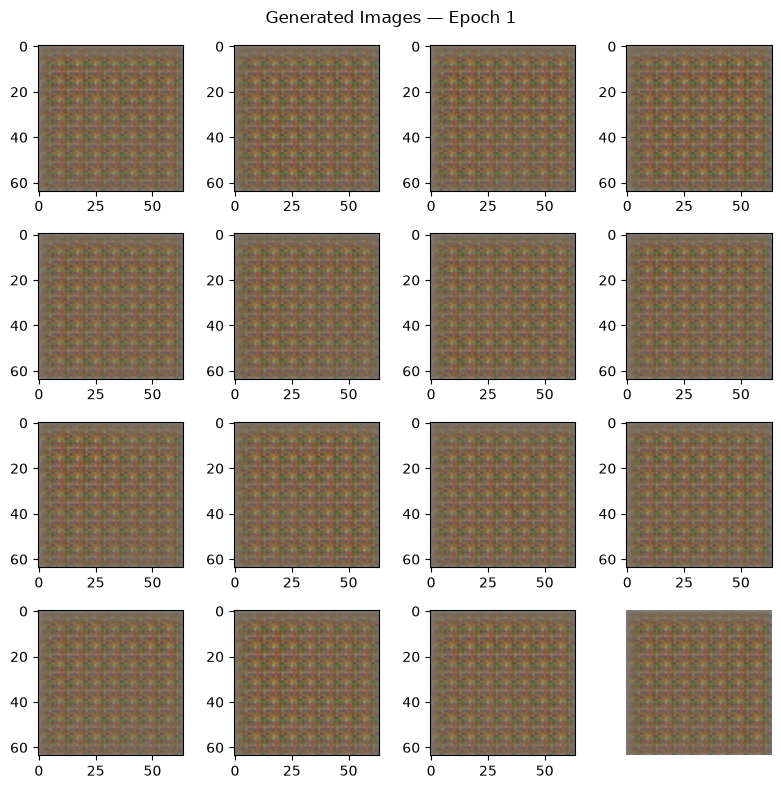

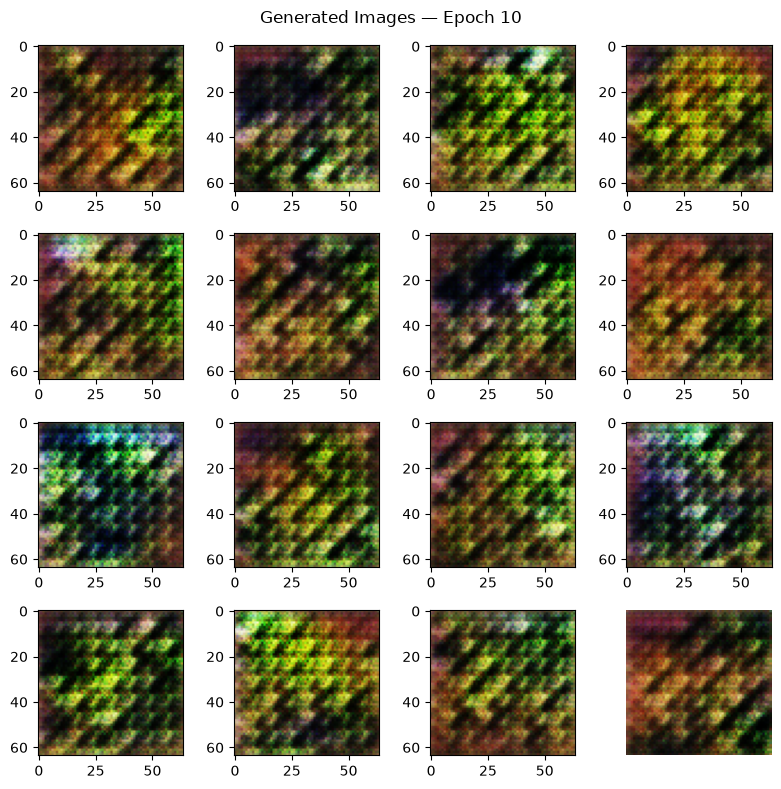

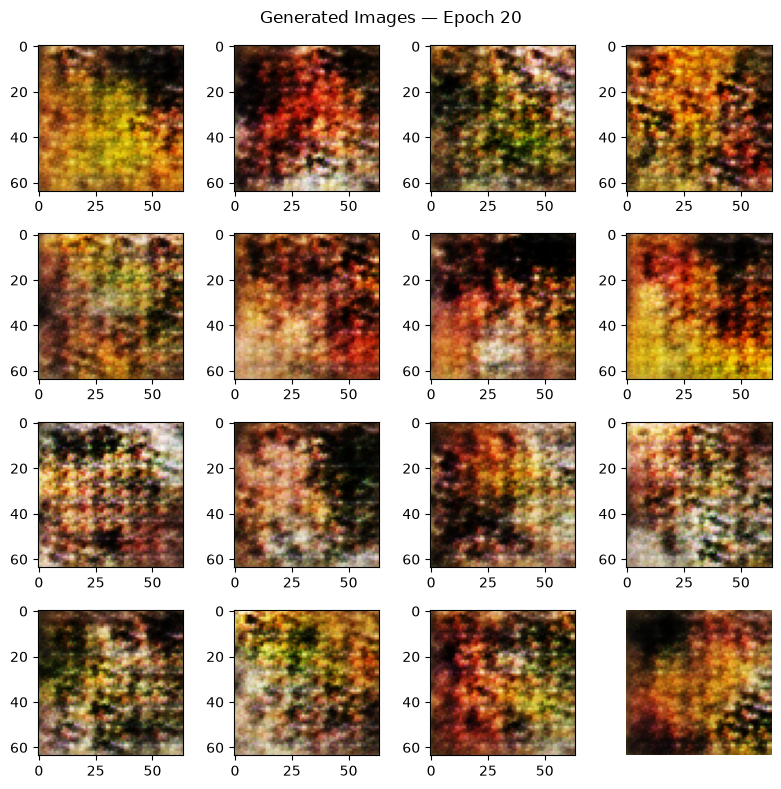

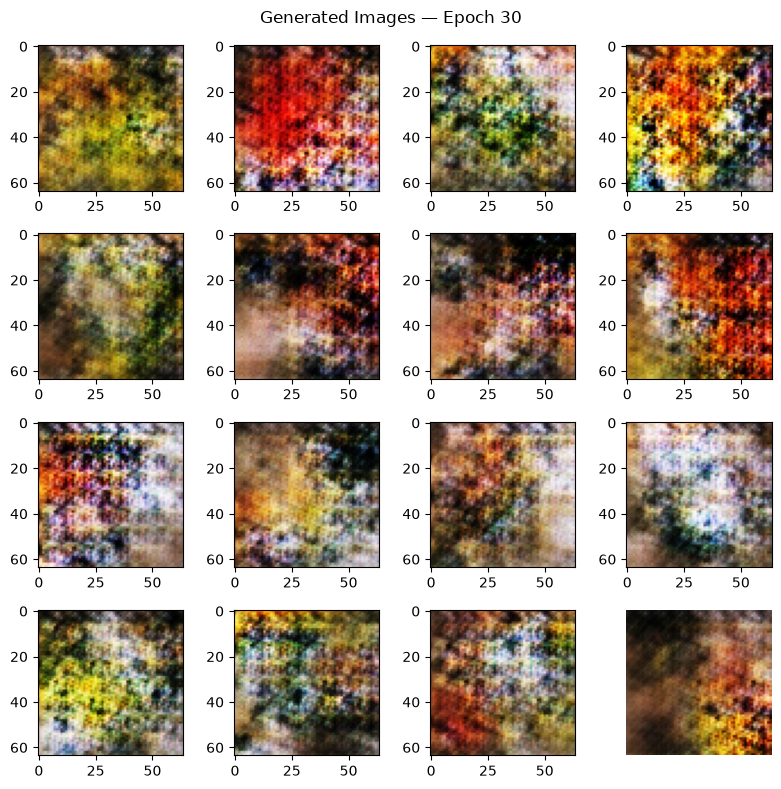

In [22]:
for ep,arr in snapshots.items():
    arr=np.clip((arr+1)/2,0,1)
    fig,ax=plt.subplots(4,4,figsize=(8,8))
    for a,img in zip(ax.flat,arr): a.imshow(img);
    a.axis("off")
    plt.suptitle(f"Generated Images — Epoch {ep}");
    plt.tight_layout();
    plt.savefig(OUTPUT_DIR/"training"/f"epoch_{ep:03d}.png",dpi=140);
    plt.show();
    plt.close()

# Final Generated Images

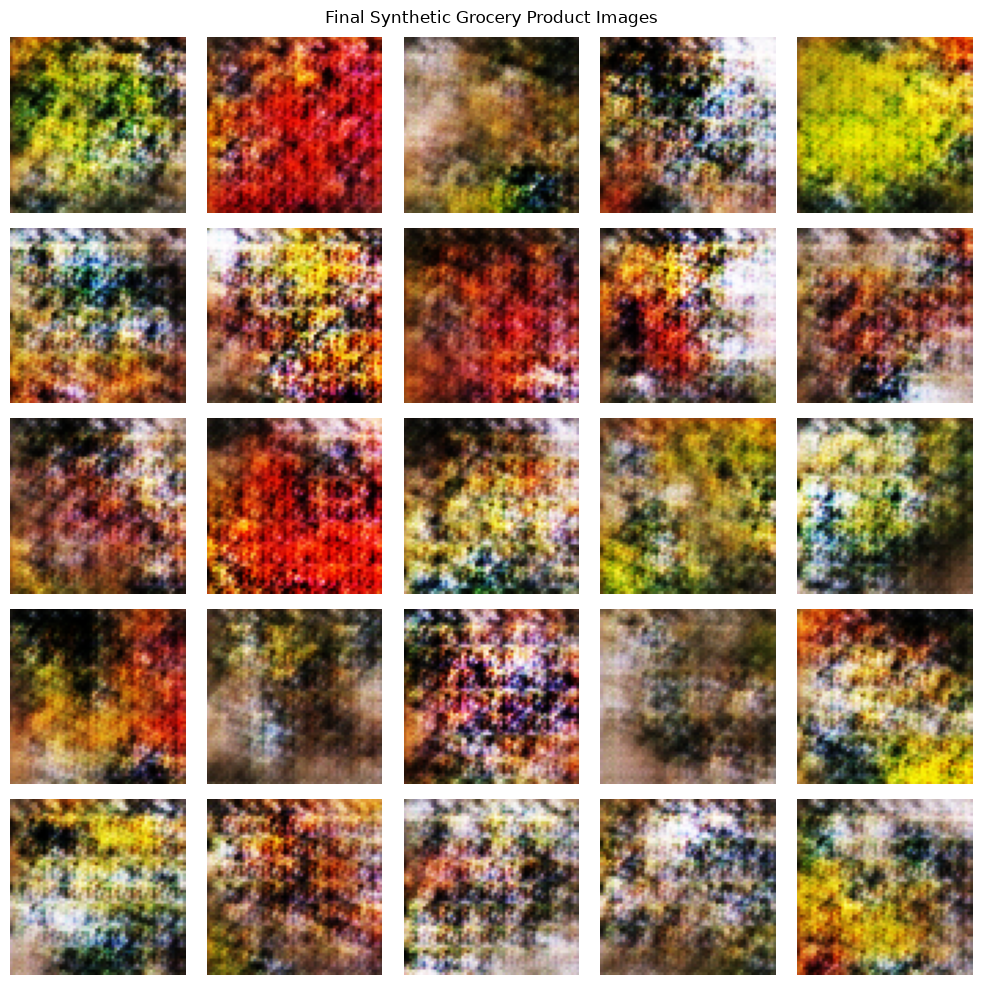

In [23]:
z=tf.random.normal([25,LATENT_DIM],seed=SEED+1)
imgs = np.clip((generator(z, training=False).numpy() + 1) / 2, 0, 1)
fig,ax=plt.subplots(5,5,figsize=(10,10))
for i,a in enumerate(ax.flat): a.imshow(imgs[i]); a.axis("off")
plt.suptitle("Final Synthetic Grocery Product Images");
plt.tight_layout();
plt.savefig(OUTPUT_DIR/"generated_images"/"final_grid.png",dpi=160);
plt.show()
for i,img in enumerate(imgs): Image.fromarray((img*255).astype("uint8")).save(OUTPUT_DIR/"generated_images"/f"generated_{i+1:02d}.png")

# Held-Out Test Evaluation — FID and KID
The test set is not used for training. Evaluation is intentionally capped for CPU/RAM safety. Interpret FID/KID together with visual quality and diversity.

In [24]:

# ============================================================
# Test Evaluation: FID and KID
# ============================================================

# ------------------------------------------------------------
# 1. Select test images
# ------------------------------------------------------------

n = min(TEST_EVAL_LIMIT, len(test_df))

test_paths = (
    test_df
    .sample(n, random_state=SEED)
    .path
    .tolist()
)

# ------------------------------------------------------------
# 2. Load real test images
# ------------------------------------------------------------

real = np.stack([
    np.asarray(
        Image.open(p).convert("RGB").resize((299, 299)),
        dtype=np.float32
    )
    for p in test_paths
])

# ------------------------------------------------------------
# 3. Prepare generated images
# ------------------------------------------------------------

fake = np.asarray(imgs[:n], dtype=np.float32)

# If generated images are in [0, 1], convert to [0, 255]
if fake.max() <= 1.0:
    fake = fake * 255.0

fake = np.clip(fake, 0, 255)

# Resize generated images to InceptionV3 input size
fake = tf.image.resize(
    fake,
    [299, 299]
).numpy().astype(np.float32)

# ------------------------------------------------------------
# 4. Load pretrained InceptionV3
# ------------------------------------------------------------

inc = InceptionV3(
    include_top=False,
    weights="imagenet",
    pooling="avg",
    input_shape=(299, 299, 3)
)

inc.trainable = False

# ------------------------------------------------------------
# 5. Feature extraction function
# ------------------------------------------------------------

def feats(x, batch_size=8):
    features = []

    for i in range(0, len(x), batch_size):

        batch = x[i:i + batch_size]

        # InceptionV3 preprocessing
        batch = preprocess_input(batch)

        # Prediction
        batch_features = inc.predict(
            batch,
            verbose=0
        )

        features.append(batch_features)

    return np.concatenate(features, axis=0)

# ------------------------------------------------------------
# 6. Extract features
# ------------------------------------------------------------

rf = feats(real)
ff = feats(fake)

print("Real feature shape:", rf.shape)
print("Fake feature shape:", ff.shape)

# ------------------------------------------------------------
# 7. Calculate FID
# ------------------------------------------------------------

m1 = np.mean(rf, axis=0)
m2 = np.mean(ff, axis=0)

if n > 1:

    s1 = np.cov(rf, rowvar=False)
    s2 = np.cov(ff, rowvar=False)

    # Numerical stability
    eps = 1e-6

    s1 = s1 + np.eye(s1.shape[0]) * eps
    s2 = s2 + np.eye(s2.shape[0]) * eps

    covmean = sqrtm(s1 @ s2)

    if np.iscomplexobj(covmean):
        covmean = np.real(covmean)

    fid = float(
        np.sum((m1 - m2) ** 2)
        + np.trace(s1 + s2 - 2 * covmean)
    )

else:
    fid = float("nan")

# ------------------------------------------------------------
# 8. Calculate KID
# ------------------------------------------------------------

if n > 1:

    d = rf.shape[1]

    kxx = ((rf @ rf.T) / d + 1) ** 3
    kyy = ((ff @ ff.T) / d + 1) ** 3
    kxy = ((rf @ ff.T) / d + 1) ** 3

    kid = float(
        (kxx.sum() - np.trace(kxx)) / (n * (n - 1))
        +
        (kyy.sum() - np.trace(kyy)) / (n * (n - 1))
        -
        2 * kxy.mean()
    )

else:
    kid = float("nan")

# ------------------------------------------------------------
# 9. Display evaluation results
# ------------------------------------------------------------

metrics = pd.DataFrame({
    "metric": [
        "FID",
        "KID",
        "test_images"
    ],
    "value": [
        fid,
        kid,
        n
    ]
})

display(metrics)

# ------------------------------------------------------------
# 10. Save results
# ------------------------------------------------------------

evaluation_dir = OUTPUT_DIR / "evaluation"
evaluation_dir.mkdir(parents=True, exist_ok=True)

metrics.to_csv(
    evaluation_dir / "test_metrics.csv",
    index=False
)

print("\nEvaluation completed successfully.")
print(f"FID: {fid:.4f}")
print(f"KID: {kid:.6f}")
print(f"Test images evaluated: {n}")

Real feature shape: (300, 2048)
Fake feature shape: (25, 2048)


,metric,value
0,FID,443.759934
1,KID,-1.110710
2,test_images,300.000000



Evaluation completed successfully.
FID: 443.7599
KID: -1.110710
Test images evaluated: 300


# Image Quality and Error Analysis
Check brightness, contrast and diversity alongside FID/KID.

Typical GAN failure modes:
- mode collapse
- unstable losses
- noisy/poor images
- distribution mismatch
- dataset imbalance
- 64×64 resolution limitation

Classic supervised bias/variance is not directly defined for GANs; use train/validation loss gaps, held-out metrics and visual diversity as diagnostics.

In [25]:
real64=np.stack([np.asarray(Image.open(p).convert("RGB").resize((64,64)),dtype=np.float32)/255 for p in test_paths[:min(50,n)]])
fake64=imgs[:len(real64)]
def diversity(a):
    x=a.reshape(len(a),-1); ds=[]
    for i in range(min(30,len(x))): ds.extend(np.linalg.norm(x[i+1:]-x[i],axis=1))
    return float(np.mean(ds)) if ds else np.nan
diag=pd.DataFrame({"metric":["real_brightness","generated_brightness","real_contrast","generated_contrast","real_diversity","generated_diversity"],"value":[real64.mean(),fake64.mean(),real64.std(),fake64.std(),diversity(real64),diversity(fake64)]})
display(diag);
diag.to_csv(OUTPUT_DIR/"evaluation"/"image_quality.csv",index=False)

,metric,value
0,real_brightness,0.408767
1,generated_brightness,0.390039
2,real_contrast,0.253923
3,generated_contrast,0.264064
4,real_diversity,35.369869
5,generated_diversity,34.898586


# Three Required Experiments

| Experiment | LR | Beta1 | Dropout | Latent |
|---|---:|---:|---:|---:|
| Baseline | 0.0002 | 0.5 | 0.30 | 100 |
| Stronger discriminator regularization | 0.0002 | 0.5 | 0.40 | 100 |
| Lower LR + larger latent space | 0.0001 | 0.5 | 0.30 | 128 |



In [26]:
experiments=pd.DataFrame([
{"experiment":"Baseline","lr":.0002,"beta1":.5,"dropout":.30,"latent_dim":100},
{"experiment":"Dropout 0.40","lr":.0002,"beta1":.5,"dropout":.40,"latent_dim":100},
{"experiment":"LR 0.0001 + latent 128","lr":.0001,"beta1":.5,"dropout":.30,"latent_dim":128}
])
experiments.to_csv(OUTPUT_DIR/"experiments"/"experiment_plan.csv",index=False)
display(experiments)

,experiment,lr,beta1,dropout,latent_dim
0,Baseline,0.0002,0.5,0.3,100
1,Dropout 0.40,0.0002,0.5,0.4,100
2,LR 0.0001 + latent 128,0.0001,0.5,0.3,128


# Controlled Distribution
For product-specific/controlled generation without changing the Basic GAN architecture, filter the training population before training.

Example:
```python
MODEL_SCOPE="category"
TARGET_VALUE="Fruit"
```
or:
```python
MODEL_SCOPE="product"
TARGET_VALUE="Apple"
```


## Deployment architecture

`JSON input → validation → latent noise → trained Generator → PNG/Base64 → JSON response`

For this GAN, "preprocessing" at the API layer means validating `num_images` and preparing the latent-space input. There is no uploaded image to resize because the Generator accepts random noise.


In [27]:


import shutil


ROOT_GENERATED_DIR = PROJECT_DIR / "generated_images"
SCREENSHOT_DIR = PROJECT_DIR / "Screenshots"

for folder in [MODEL_DIR, ROOT_GENERATED_DIR, SCREENSHOT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

GENERATOR_PATH = MODEL_DIR / "generator.keras"
DISCRIMINATOR_PATH = MODEL_DIR / "discriminator.keras"

print("Project:", PROJECT_DIR.resolve())
print("Generator:", GENERATOR_PATH.resolve())


Project: C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project
Generator: C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\model\generator.keras



## Save the trained models

In [28]:
if "generator" not in globals() or "discriminator" not in globals():
    raise RuntimeError(
        "Run the approved notebook from the beginning through the final training cell first. "
        "The trained generator/discriminator must exist in memory."
    )

generator.save(GENERATOR_PATH)
discriminator.save(DISCRIMINATOR_PATH)

print("Generator:", GENERATOR_PATH, round(GENERATOR_PATH.stat().st_size/1024**2, 2), "MB")
print("Discriminator:", DISCRIMINATOR_PATH, round(DISCRIMINATOR_PATH.stat().st_size/1024**2, 2), "MB")


Generator: c:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\model\generator.keras 10.47 MB
Discriminator: c:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\model\discriminator.keras 4.03 MB


In [29]:

# root-level files requested in the submission structure.

ROOT_GENERATOR = PROJECT_DIR / "generator.keras"
ROOT_DISCRIMINATOR = PROJECT_DIR / "discriminator.keras"

shutil.copy2(GENERATOR_PATH, ROOT_GENERATOR)
shutil.copy2(DISCRIMINATOR_PATH, ROOT_DISCRIMINATOR)

print("Root Generator:", ROOT_GENERATOR)
print("Root Discriminator:", ROOT_DISCRIMINATOR)


Root Generator: c:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\generator.keras
Root Discriminator: c:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\discriminator.keras


In [30]:

training_dir = OUTPUT_DIR / "training"

epoch_files = {
    "epoch_1.png": training_dir / "epoch_001.png",
    "epoch_10.png": training_dir / "epoch_010.png",
    "epoch_20.png": training_dir / "epoch_020.png",
    "epoch_30.png": training_dir / "epoch_030.png",
}

copied = []
for target, source in epoch_files.items():
    if source.exists():
        shutil.copy2(source, ROOT_GENERATED_DIR / target)
        copied.append(target)

final_grid = OUTPUT_DIR / "generated_images" / "final_grid.png"
if final_grid.exists():
    shutil.copy2(final_grid, ROOT_GENERATED_DIR / "final_grid.png")
    copied.append("final_grid.png")

print("Copied:", copied)


Copied: ['epoch_1.png', 'epoch_10.png', 'epoch_20.png', 'epoch_30.png', 'final_grid.png']


In [31]:

# Create app.py
app_code = 'from pathlib import Path\nfrom io import BytesIO\nimport base64\n\nimport numpy as np\nimport tensorflow as tf\nfrom fastapi import FastAPI, HTTPException\nfrom pydantic import BaseModel, Field\nfrom PIL import Image\n\nIMAGE_SIZE = 64\nLATENT_DIM = 100\nMAX_IMAGES = 16\nGENERATION_BATCH_SIZE = 4\n\nBASE_DIR = Path(__file__).resolve().parent\nMODEL_PATH = BASE_DIR / "model" / "generator.keras"\n\napp = FastAPI(\n    title="Product Image Generation - Basic GAN API",\n    description="Generate synthetic grocery product images using the trained Basic GAN Generator.",\n    version="1.0.0",\n)\n\nif not MODEL_PATH.exists():\n    raise FileNotFoundError(\n        f"Trained Generator not found: {MODEL_PATH}. "\n        "Place generator.keras inside the model folder."\n    )\n\ngenerator = tf.keras.models.load_model(MODEL_PATH, compile=False)\n\n\nclass GenerateRequest(BaseModel):\n    num_images: int = Field(default=1, ge=1, le=MAX_IMAGES)\n\n\ndef tensor_to_base64_png(image_tensor):\n    image = (image_tensor + 1.0) / 2.0\n    image = np.clip(image, 0.0, 1.0)\n    image = (image * 255.0).astype(np.uint8)\n\n    pil_image = Image.fromarray(image, mode="RGB")\n    buffer = BytesIO()\n    pil_image.save(buffer, format="PNG", optimize=True)\n\n    return base64.b64encode(buffer.getvalue()).decode("utf-8")\n\n\n@app.get("/")\ndef root():\n    return {\n        "project": "Product Image Generation using Basic GAN",\n        "status": "running",\n        "endpoint": "POST /generate"\n    }\n\n\n@app.get("/health")\ndef health():\n    return {\n        "status": "healthy",\n        "model_loaded": generator is not None,\n        "image_size": IMAGE_SIZE,\n        "latent_dimension": LATENT_DIM,\n        "max_images_per_request": MAX_IMAGES\n    }\n\n\n@app.post("/generate")\ndef generate_images(request: GenerateRequest):\n    try:\n        num_images = int(request.num_images)\n    except Exception:\n        raise HTTPException(status_code=400, detail="num_images must be an integer.")\n\n    if not 1 <= num_images <= MAX_IMAGES:\n        raise HTTPException(\n            status_code=400,\n            detail=f"num_images must be between 1 and {MAX_IMAGES}."\n        )\n\n    images = []\n\n    # Small batches reduce peak RAM usage.\n    for start in range(0, num_images, GENERATION_BATCH_SIZE):\n        current_size = min(GENERATION_BATCH_SIZE, num_images - start)\n\n        latent_vectors = tf.random.normal(\n            shape=(current_size, LATENT_DIM)\n        )\n\n        generated = generator(latent_vectors, training=False).numpy()\n\n        for image_tensor in generated:\n            images.append(tensor_to_base64_png(image_tensor))\n\n        del latent_vectors\n        del generated\n\n    return {\n        "status": "success",\n        "num_images": len(images),\n        "image_size": f"{IMAGE_SIZE}x{IMAGE_SIZE}",\n        "format": "PNG",\n        "encoding": "base64",\n        "images": images\n    }\n'
app_path = PROJECT_DIR / "app.py"
app_path.write_text(app_code, encoding="utf-8")
print("Created:", app_path.resolve())


Created: C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\app.py


In [32]:

# Validate deployment source and model
app_text = (PROJECT_DIR / "app.py").read_text(encoding="utf-8")

required_terms = [
    "FastAPI",
    "generator.keras",
    "LATENT_DIM = 100",
    "@app.post",
    "base64",
    "tf.random.normal",
    "compile=False",
]

missing = [x for x in required_terms if x not in app_text]

assert GENERATOR_PATH.exists(), "generator.keras was not saved."
assert not missing, f"Missing deployment terms: {missing}"

print("Deployment source check: PASS")


Deployment source check: PASS



# Phase 14: Streamlit UI

This lightweight UI calls FastAPI rather than loading TensorFlow itself, reducing memory usage.


In [33]:

# Create ui.py
ui_code = 'import base64\nfrom io import BytesIO\n\nimport requests\nimport streamlit as st\nfrom PIL import Image\n\nst.set_page_config(\n    page_title="Product Image Generator",\n    page_icon="🛒",\n    layout="wide"\n)\n\nst.title("Product Image Generation using Basic GAN")\nst.write("Generate synthetic grocery product images using the trained Basic GAN Generator.")\n\napi_url = st.text_input("FastAPI URL", "http://127.0.0.1:8000")\n\nnum_images = st.number_input(\n    "Number of images",\n    min_value=1,\n    max_value=16,\n    value=5,\n    step=1\n)\n\nif st.button("Generate Images"):\n    try:\n        response = requests.post(\n            f"{api_url}/generate",\n            json={"num_images": int(num_images)},\n            timeout=120\n        )\n        response.raise_for_status()\n        result = response.json()\n\n        st.success(f"Generated {result[\'num_images\']} images.")\n\n        columns = st.columns(4)\n        for i, encoded in enumerate(result["images"]):\n            image = Image.open(BytesIO(base64.b64decode(encoded)))\n            with columns[i % 4]:\n                st.image(image, caption=f"Generated Product {i + 1}", use_container_width=True)\n\n    except requests.exceptions.RequestException as exc:\n        st.error("Could not connect to FastAPI. Start the API first.")\n        st.code(str(exc))\n'
ui_path = PROJECT_DIR / "ui.py"
ui_path.write_text(ui_code, encoding="utf-8")
print("Created:", ui_path.resolve())


Created: C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\ui.py



# Phase 15: Docker

The container runs FastAPI and loads only the Generator. 

In [35]:

# 15. Create requirements.txt
requirements = '''tensorflow==2.21.0
fastapi==0.116.1
uvicorn[standard]==0.35.0
pydantic==2.11.7
numpy==2.1.3
pillow==11.3.0
requests==2.32.4
streamlit==1.48.1
'''

requirements_path = PROJECT_DIR / "requirements.txt"
requirements_path.write_text(requirements, encoding="utf-8")
print(requirements_path.read_text())


tensorflow==2.21.0
fastapi==0.116.1
uvicorn[standard]==0.35.0
pydantic==2.11.7
numpy==2.1.3
pillow==11.3.0
requests==2.32.4
streamlit==1.48.1



In [36]:

# 15.2 Create Dockerfile
dockerfile = '''FROM python:3.11-slim

WORKDIR /app

ENV PYTHONUNBUFFERED=1
ENV TF_CPP_MIN_LOG_LEVEL=2

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY model ./model

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

docker_path = PROJECT_DIR / "Dockerfile"
docker_path.write_text(dockerfile, encoding="utf-8")
print(docker_path.read_text())


FROM python:3.11-slim

WORKDIR /app

ENV PYTHONUNBUFFERED=1
ENV TF_CPP_MIN_LOG_LEVEL=2

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py .
COPY model ./model

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]



In [41]:

# 15.3 Create .dockerignore
dockerignore = '''__pycache__/
*.pyc
.ipynb_checkpoints/
data/
outputs/eda/
outputs/evaluation/
outputs/experiments/
outputs/reports/
Screenshots/
.git/
'''

path = PROJECT_DIR / ".dockerignore"
path.write_text(dockerignore, encoding="utf-8")
print("Created:", path)


Created: c:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\.dockerignore


In [43]:
from pathlib import Path

print(Path.cwd())

print(PROJECT_DIR.resolve())

c:\Users\ADMIN\OneDrive\Desktop\main project
C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project



# Phase 16: README


In [44]:

# 16.1 Create README.md
readme = '# Product Image Generation using Basic GAN\n\n## 1. Project Overview\n\n**Problem:** Retail and grocery applications may require large collections of product images for prototyping, computer-vision experimentation, testing and synthetic-data research.\n\n**Objective:** Train a Basic Generative Adversarial Network using the GroceryStoreDataset and generate synthetic grocery product images.\n\n**Real-world application:** Synthetic product images can support catalog prototyping, image-pipeline testing and data-augmentation research. Generated images are synthetic and are not verified product photographs.\n\n## 2. Dataset\n\nDataset: GroceryStoreDataset  \nSource: https://github.com/marcusklasson/GroceryStoreDataset\n\nThe approved notebook performs image validation, EDA, leakage-aware splitting and preprocessing.\n\nGAN input: random latent vector of dimension 100.  \nGAN output: 64×64 RGB synthetic product image.\n\n## 3. Technology Stack\n\nPython, NumPy, Pandas, Matplotlib, Pillow, TensorFlow/Keras, FastAPI, Uvicorn, Streamlit, Docker, Git/GitHub.\n\n## 4. Workflow\n\n```text\nDataset\n→ Dataset Understanding\n→ EDA\n→ Data Quality\n→ Train/Validation/Test Split\n→ 64×64 RGB Preprocessing\n→ Basic GAN\n→ Training\n→ Experiments\n→ Evaluation\n→ Final Generator\n→ FastAPI\n→ JSON Output\n→ Docker\n```\n\n## 5. Model Architecture\n\n### Generator\n\n```text\nLatent 100\n→ Dense 8×8×256\n→ BatchNorm\n→ ReLU\n→ Reshape\n→ Conv2DTranspose 128\n→ BatchNorm\n→ ReLU\n→ Conv2DTranspose 64\n→ BatchNorm\n→ ReLU\n→ Conv2DTranspose 3\n→ Tanh\n→ 64×64×3\n```\n\n### Discriminator\n\n```text\n64×64×3\n→ Conv2D 64\n→ LeakyReLU(0.2)\n→ Dropout(0.30)\n→ Conv2D 128\n→ LeakyReLU(0.2)\n→ Dropout(0.30)\n→ Conv2D 256\n→ LeakyReLU(0.2)\n→ Dropout(0.30)\n→ Flatten\n→ Dense(1)\n→ Sigmoid\n```\n\n### Approved configuration\n\n| Parameter | Value |\n|---|---:|\n| Image size | 64×64 |\n| Channels | RGB |\n| Latent dimension | 100 |\n| Batch size | 16 |\n| Epochs | 30 |\n| Optimizer | Adam |\n| Learning rate | 0.0002 |\n| Beta1 | 0.5 |\n| Loss | Binary Cross-Entropy |\n| Generator output | Tanh |\n\n## 6. Experiments\n\n1. Baseline: LR 0.0002, Beta1 0.5, Dropout 0.30, Latent 100\n2. Dropout 0.40: LR 0.0002, Beta1 0.5, Dropout 0.40, Latent 100\n3. LR 0.0001 + Latent 128: LR 0.0001, Beta1 0.5, Dropout 0.30, Latent 128\n\n## 7. Evaluation\n\nGenerator loss, discriminator loss, FID, KID, brightness, contrast, diversity, generated-image visualization, stability and mode-collapse observations.\n\nGAN losses are interpreted together with visual quality and diversity rather than as an accuracy score.\n\n## 8. Deployment\n\nFastAPI endpoints:\n\n- `GET /`\n- `GET /health`\n- `POST /generate`\n\nRequest:\n\n```json\n{"num_images": 5}\n```\n\nResponse contains JSON metadata and Base64-encoded PNG images.\n\nSwagger UI:\n\n`http://localhost:8000/docs`\n\n## 9. UI\n\n`ui.py` provides a lightweight Streamlit interface that calls FastAPI.\n\n```bash\nstreamlit run ui.py\n```\n\n## 10. Docker\n\nBuild:\n\n```bash\ndocker build -t product-gan-api .\n```\n\nRun:\n\n```bash\ndocker run --rm -p 8000:8000 product-gan-api\n```\n\n## 11. Limitations\n\n- 64×64 resolution\n- possible GAN artifacts\n- possible mode collapse\n- training instability\n- CPU training/generation is slower than GPU execution\n- synthetic images should not be treated as verified product photographs\n\n## 12. Future Scope\n\nHigher resolution, larger datasets, conditional generation, improved GAN architectures, stronger diversity evaluation, GPU training and production monitoring.\n\n## 13. Project Structure\n\n```text\nProject_Name/\n├── Project_Notebook.ipynb\n├── generator.keras\n├── discriminator.keras\n├── app.py\n├── ui.py\n├── requirements.txt\n├── Dockerfile\n├── .dockerignore\n├── .gitignore\n├── README.md\n├── model/\n│   ├── generator.keras\n│   └── discriminator.keras\n├── generated_images/\n│   ├── epoch_1.png\n│   ├── epoch_10.png\n│   ├── epoch_20.png\n│   ├── epoch_30.png\n│   └── final_grid.png\n├── Screenshots/\n└── outputs/\n```\n\n## 14. Final demonstration\n\nProblem → Dataset → EDA → Preprocessing → Representation → Generator → Discriminator → Training → Experiments → Evaluation → Error Analysis → FastAPI → JSON generation → Docker → UI → Limitations → Future scope.\n'
readme_path = PROJECT_DIR / "README.md"
readme_path.write_text(readme, encoding="utf-8")
print("Created:", readme_path.resolve())


Created: C:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\README.md


In [45]:

# 16.2 Create .gitignore
gitignore = '''__pycache__/
*.py[cod]
.ipynb_checkpoints/
.venv/
venv/
env/
.DS_Store
Thumbs.db
data/
*.log
'''

path = PROJECT_DIR / ".gitignore"
path.write_text(gitignore, encoding="utf-8")
print("Created:", path)


Created: c:\Users\ADMIN\OneDrive\Desktop\main project\GroceryStore_GAN_Project\.gitignore



# Phase 17: Required-file validation


In [46]:

required = [
    "app.py",
    "ui.py",
    "requirements.txt",
    "Dockerfile",
    ".dockerignore",
    ".gitignore",
    "README.md",
    "generator.keras",
    "discriminator.keras",
    "model/generator.keras",
    "model/discriminator.keras",
]

rows = []
for rel in required:
    p = PROJECT_DIR / rel
    rows.append({
        "file": rel,
        "exists": p.exists(),
        "size_MB": round(p.stat().st_size/1024**2, 2) if p.exists() else None
    })

check_df = pd.DataFrame(rows)
display(check_df)

missing = check_df.loc[~check_df["exists"], "file"].tolist()
print("FINAL FILE CHECK:", "PASS" if not missing else f"Missing: {missing}")


,file,exists,size_MB
0,app.py,True,0.00
1,ui.py,True,0.00
2,requirements.txt,True,0.00
3,Dockerfile,True,0.00
4,.dockerignore,True,0.00
5,.gitignore,True,0.00
6,README.md,True,0.00
7,generator.keras,True,10.47
8,discriminator.keras,True,4.03
9,model/generator.keras,True,10.47


FINAL FILE CHECK: PASS



# Phase 18: Test the running API from the notebook

First start FastAPI separately:

```bash
uvicorn app:app --host 127.0.0.1 --port 8000
```

Then run the next cell.


Health: 200
{'status': 'healthy', 'model_loaded': True, 'image_size': 64, 'latent_dimension': 100, 'max_images_per_request': 16}

Generate: 200
Returned: 2
Size: 64x64
First image: (64, 64) RGB


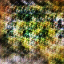

In [47]:

import requests
import base64
from io import BytesIO
from PIL import Image

API_URL = "http://127.0.0.1:8000"

try:
    health = requests.get(f"{API_URL}/health", timeout=10)
    print("Health:", health.status_code)
    print(health.json())

    response = requests.post(
        f"{API_URL}/generate",
        json={"num_images": 2},
        timeout=120
    )
    print("\nGenerate:", response.status_code)

    result = response.json()
    print("Returned:", result.get("num_images"))
    print("Size:", result.get("image_size"))

    if response.ok and result.get("images"):
        image = Image.open(BytesIO(base64.b64decode(result["images"][0])))
        print("First image:", image.size, image.mode)
        display(image)

except requests.exceptions.RequestException as exc:
    print("API is not running yet.")
    print("Start it with: uvicorn app:app --host 127.0.0.1 --port 8000")
    print(exc)
